In [2]:
import pandas as pd
import numpy as np
import wfdb

In [18]:
data = pd.read_csv("ptbxl.3/ptbxl_database.csv")

print(data.head())

   ecg_id  patient_id   age  sex  height  weight  nurse  site     device  \
0       1     15709.0  56.0    1     NaN    63.0    2.0   0.0  CS-12   E   
1       2     13243.0  19.0    0     NaN    70.0    2.0   0.0  CS-12   E   
2       3     20372.0  37.0    1     NaN    69.0    2.0   0.0  CS-12   E   
3       4     17014.0  24.0    0     NaN    82.0    2.0   0.0  CS-12   E   
4       5     17448.0  19.0    1     NaN    70.0    2.0   0.0  CS-12   E   

        recording_date  ... validated_by_human  baseline_drift static_noise  \
0  1984-11-09 09:17:34  ...               True             NaN    , I-V1,     
1  1984-11-14 12:55:37  ...               True             NaN          NaN   
2  1984-11-15 12:49:10  ...               True             NaN          NaN   
3  1984-11-15 13:44:57  ...               True    , II,III,AVF          NaN   
4  1984-11-17 10:43:15  ...               True   , III,AVR,AVF          NaN   

  burst_noise electrodes_problems  extra_beats  pacemaker  strat_fol

In [4]:
pip install tqdm

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os, ast, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm         
 
import wfdb

from scipy.signal import butter, filtfilt
 
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR
 
from sklearn.metrics import (
    roc_auc_score, f1_score, confusion_matrix,
    classification_report, roc_curve
)
 
warnings.filterwarnings("ignore")
 
# ── Reproducibility ───────────────────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED)
 
# ── CPU Performance tweaks ────────────────────────────────────────────────
torch.set_num_threads(os.cpu_count())          # use ALL cpu cores
  # faster ops on CPU
 
# ── CONFIG ────────────────────────────────────────────────────────────────
CFG = {
    "data_path"    : "C:/Users/polag/OneDrive/AKSHITHA/Projects/MAJOR PROJECT/ptbxl.3/",
    "sampling_rate": 100,
    "num_leads"    : 12,
    "seq_len"      : 1000,
 
    # ── CPU-optimized values ──────────────────────────────────────────────
    "batch_size"   : 128,    # larger batch = fewer steps = faster per epoch
    "epochs"       : 30,     # 30 is enough for good results on CPU
    "lr"           : 1e-3,
    "weight_decay" : 1e-4,
    "num_workers"  : 0,      # MUST be 0 on Windows Jupyter
 
    "device"       : "cpu",
    "checkpoint"   : "best_ecg_model.pt",
    "results_dir"  : "./results/",
    "cache_X"      : "X_ptbxl.npy",
    "cache_y"      : "y_ptbxl.npy",
    "cache_df"     : "df_filtered.csv",
}
 
Path(CFG["results_dir"]).mkdir(exist_ok=True)
print(f"✓ Device       : {CFG['device']}")
print(f"✓ CPU cores    : {os.cpu_count()}")
print(f"✓ Torch threads: {torch.get_num_threads()}")
print(f"✓ PyTorch      : {torch.__version__}")

✓ Device       : cpu
✓ CPU cores    : 16
✓ Torch threads: 16
✓ PyTorch      : 2.9.0+cpu


In [4]:
def load_ptbxl_metadata(data_path):
    df = pd.read_csv(os.path.join(data_path, "ptbxl_database.csv"), index_col="ecg_id")
    df.scp_codes = df.scp_codes.apply(ast.literal_eval)
    return df
 
 
def extract_labels(df, data_path):
    agg = pd.read_csv(os.path.join(data_path, "scp_statements.csv"), index_col=0)
    agg = agg[agg.diagnostic == 1]
 
    def get_superclass(scp_dict):
        return list(set(
            agg.loc[code, "diagnostic_class"]
            for code in scp_dict if code in agg.index
        ))
 
    df = df.copy()
    df["superclass"] = df.scp_codes.apply(get_superclass)
    df["label"] = df["superclass"].apply(
        lambda x: 1 if "MI" in x else (0 if "NORM" in x else -1)
    )
    return df
 
 
def load_waveforms(df, sampling_rate, data_path):
    key = "filename_lr" if sampling_rate == 100 else "filename_hr"
    records, errors = [], 0
 
    pbar = tqdm(df[key], desc="Loading waveforms", unit="rec")
    for fname in pbar:
        full_path = os.path.join(data_path, fname).replace("/", os.sep)
        try:
            signal, _ = wfdb.rdsamp(full_path)
            records.append(signal.astype(np.float32))
        except FileNotFoundError:
            # Fallback: reconstruct path component by component
            parts = fname.replace("\\", "/").split("/")
            alt   = os.path.join(data_path, *parts)
            try:
                signal, _ = wfdb.rdsamp(alt)
                records.append(signal.astype(np.float32))
            except Exception:
                records.append(np.zeros((1000, 12), dtype=np.float32))
                errors += 1
    if errors:
        print(f"⚠️  {errors} records zero-filled (not found)")
    return np.array(records, dtype=np.float32)   # (N, T, 12)
 
 
def load_or_cache(cfg):
    cx, cy, cd = cfg["cache_X"], cfg["cache_y"], cfg["cache_df"]
 
    if os.path.exists(cx) and os.path.exists(cy) and os.path.exists(cd):
        print("✓ Cache found — loading instantly...")
        X_raw       = np.load(cx)
        y           = np.load(cy)
        df_filtered = pd.read_csv(cd, index_col="ecg_id")
        print(f"  X: {X_raw.shape}  |  MI: {int(y.sum())}  |  NORM: {int((y==0).sum())}")
        return X_raw, y, df_filtered
 
    print("No cache — loading from disk (one-time, ~5 min)...")
    df          = load_ptbxl_metadata(cfg["data_path"])
    df          = extract_labels(df, cfg["data_path"])
    df_filtered = df[df["label"] != -1].copy()
    print(f"  Records: {len(df_filtered)} | MI: {(df_filtered.label==1).sum()} | NORM: {(df_filtered.label==0).sum()}")
 
    X_raw = load_waveforms(df_filtered, cfg["sampling_rate"], cfg["data_path"])
    y     = df_filtered["label"].values.astype(np.float32)
 
    np.save(cx, X_raw); np.save(cy, y); df_filtered.to_csv(cd)
    print(f"✓ Cache saved — next run will be instant!")
    return X_raw, y, df_filtered
 
 
X_raw, y, df_filtered = load_or_cache(CFG)
print(f"\n✓ Loaded: X={X_raw.shape}  y={y.shape}")

✓ Cache found — loading instantly...
  X: (14982, 1000, 12)  |  MI: 5469  |  NORM: 9513

✓ Loaded: X=(14982, 1000, 12)  y=(14982,)


Preprocessing signals...


Preprocessing: 100%|███████████████████████████████████████████████████████████| 14982/14982 [00:57<00:00, 259.55rec/s]


✓ Shape: (14982, 12, 1000)  →  (records, leads, timesteps)


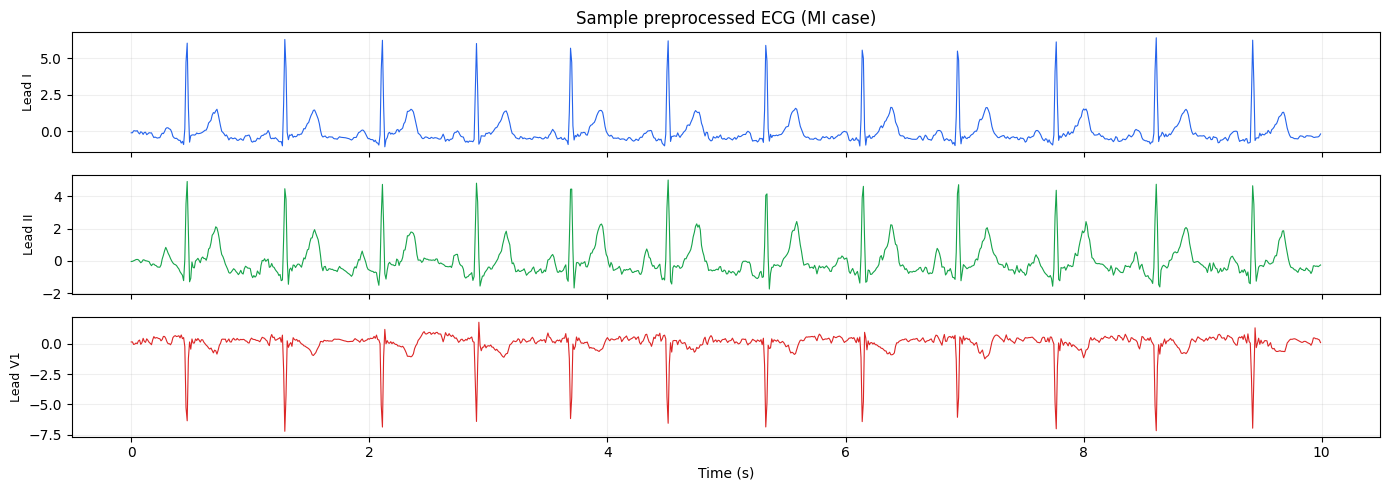

✓ Sample ECG saved


In [6]:
def bandpass_filter(signal, lowcut=0.5, highcut=40.0, fs=100, order=4):
    nyq = fs / 2.0
    b, a = butter(order, [lowcut/nyq, highcut/nyq], btype="band")
    return filtfilt(b, a, signal, axis=0).astype(np.float32)
 
def remove_baseline_wander(signal, fs=100, cutoff=0.5, order=2):
    nyq = fs / 2.0
    b, a = butter(order, cutoff/nyq, btype="high")
    return filtfilt(b, a, signal, axis=0).astype(np.float32)
 
def zscore_normalize(signal):
    mean = signal.mean(axis=0, keepdims=True)
    std  = signal.std(axis=0, keepdims=True) + 1e-8
    return (signal - mean) / std
 
def preprocess_signals(X, fs=100):
    """(N,T,12) → (N,12,T) channels-first for PyTorch"""
    processed = []
    for sig in tqdm(X, desc="Preprocessing", unit="rec"):
        sig = remove_baseline_wander(sig, fs=fs)
        sig = bandpass_filter(sig, fs=fs)
        sig = zscore_normalize(sig)
        processed.append(sig)
    out = np.stack(processed, axis=0)       # (N, T, 12)
    return out.transpose(0, 2, 1)           # (N, 12, T)
 
 
print("Preprocessing signals...")
X = preprocess_signals(X_raw, fs=CFG["sampling_rate"])
print(f"✓ Shape: {X.shape}  →  (records, leads, timesteps)")
 
# Quick sanity plot
fig, axes = plt.subplots(3, 1, figsize=(14, 5), sharex=True)
mi_idx = np.where(y == 1)[0][0]
for i, (ax, name, col) in enumerate(zip(
    axes,
    ["Lead I", "Lead II", "Lead V1"],
    ["#2563EB", "#16A34A", "#DC2626"]
)):
    ax.plot(np.arange(1000)/100, X[mi_idx, i], color=col, linewidth=0.8)
    ax.set_ylabel(name, fontsize=9); ax.grid(True, alpha=0.2)
axes[0].set_title("Sample preprocessed ECG (MI case)")
axes[-1].set_xlabel("Time (s)")
plt.tight_layout(); plt.savefig(f"{CFG['results_dir']}sample_ecg.png", dpi=120)
plt.show()
print("✓ Sample ECG saved")

In [7]:
class ECGDataset(Dataset):
    def __init__(self, X, y, augment=False):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
        self.augment = augment
 
    def __len__(self): return len(self.y)
 
    def __getitem__(self, idx):
        x = self.X[idx].clone()
        if self.augment:
            # Gaussian noise
            if random.random() < 0.5:
                x += 0.01 * torch.randn_like(x)
            # Time shift
            if random.random() < 0.5:
                x = torch.roll(x, random.randint(-50, 50), dims=-1)
            # Lead dropout
            if random.random() < 0.3:
                leads = random.sample(range(x.shape[0]), random.randint(1,2))
                x[leads] = 0.0
        return x, self.y[idx]
 
 
def build_dataloaders(X, y, df, cfg):
    id_to_pos = {eid: i for i, eid in enumerate(df.index)}
 
    def get_pos(mask):
        return np.array([id_to_pos[e] for e in df[mask].index if e in id_to_pos])
 
    tr = get_pos(df.strat_fold <= 8)
    va = get_pos(df.strat_fold == 9)
    te = get_pos(df.strat_fold == 10)
 
    kw = dict(num_workers=cfg["num_workers"], pin_memory=False)
    train_dl = DataLoader(ECGDataset(X[tr], y[tr], augment=True),
                          batch_size=cfg["batch_size"], shuffle=True,  **kw)
    val_dl   = DataLoader(ECGDataset(X[va], y[va]),
                          batch_size=cfg["batch_size"], shuffle=False, **kw)
    test_dl  = DataLoader(ECGDataset(X[te], y[te]),
                          batch_size=cfg["batch_size"], shuffle=False, **kw)
 
    print(f"✓ Train : {len(tr):5d}  (MI={int(y[tr].sum())})")
    print(f"✓ Val   : {len(va):5d}  (MI={int(y[va].sum())})")
    print(f"✓ Test  : {len(te):5d}  (MI={int(y[te].sum())})")
    return train_dl, val_dl, test_dl, tr, te
 
 
train_dl, val_dl, test_dl, tr_pos, te_pos = build_dataloaders(X, y, df_filtered, CFG)


✓ Train : 11974  (MI=4379)
✓ Val   :  1495  (MI=540)
✓ Test  :  1513  (MI=550)


In [8]:
class ResBlock1D(nn.Module):
    def __init__(self, in_ch, out_ch, kernel=15, stride=1, dropout=0.2):
        super().__init__()
        pad = kernel // 2
        self.conv = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel, stride=stride, padding=pad, bias=False),
            nn.BatchNorm1d(out_ch), nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Conv1d(out_ch, out_ch, kernel, padding=pad, bias=False),
            nn.BatchNorm1d(out_ch),
        )
        self.skip = (
            nn.Sequential(
                nn.Conv1d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm1d(out_ch),
            ) if stride != 1 or in_ch != out_ch else nn.Identity()
        )
        self.relu = nn.ReLU(inplace=True)
 
    def forward(self, x):
        return self.relu(self.conv(x) + self.skip(x))
 
 
# ── Option A: Lightweight ResNet (recommended for CPU) ───────────────────
class LightResNet1D(nn.Module):
    """
    Half the channels of full ResNet → ~4x faster on CPU.
    Still achieves good AUC (typically 0.88-0.92 on PTB-XL MI).
    """
    def __init__(self, num_leads=12, num_classes=1, dropout=0.2):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv1d(num_leads, 32, 15, padding=7, bias=False),
            nn.BatchNorm1d(32), nn.ReLU(inplace=True),
            nn.MaxPool1d(2),
        )
        self.layer1 = ResBlock1D(32,  64,  stride=2, dropout=dropout)
        self.layer2 = ResBlock1D(64,  128, stride=2, dropout=dropout)
        self.layer3 = ResBlock1D(128, 256, stride=2, dropout=dropout)
        self.layer4 = ResBlock1D(256, 256, stride=2, dropout=dropout)
        self.gap    = nn.AdaptiveAvgPool1d(1)
        self.head   = nn.Sequential(
            nn.Flatten(), nn.Dropout(dropout), nn.Linear(256, num_classes)
        )
        self._init_weights()
 
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv1d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out")
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight); nn.init.zeros_(m.bias)
 
    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x); x = self.layer2(x)
        x = self.layer3(x); x = self.layer4(x)
        return self.head(self.gap(x))
 
    def get_last_conv_features(self, x):
        """For Grad-CAM"""
        x = self.stem(x)
        x = self.layer1(x); x = self.layer2(x); x = self.layer3(x)
        return self.layer4(x)
 
 
# ── Option B: Full ResNet (better accuracy, ~4x slower) ──────────────────
class ECGResNet1D(nn.Module):
    def __init__(self, num_leads=12, num_classes=1, dropout=0.3):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv1d(num_leads, 64, 15, padding=7, bias=False),
            nn.BatchNorm1d(64), nn.ReLU(inplace=True), nn.MaxPool1d(2),
        )
        self.layer1 = ResBlock1D(64,  128, stride=2, dropout=dropout)
        self.layer2 = ResBlock1D(128, 256, stride=2, dropout=dropout)
        self.layer3 = ResBlock1D(256, 512, stride=2, dropout=dropout)
        self.layer4 = ResBlock1D(512, 512, stride=2, dropout=dropout)
        self.gap    = nn.AdaptiveAvgPool1d(1)
        self.head   = nn.Sequential(
            nn.Flatten(), nn.Dropout(dropout), nn.Linear(512, num_classes)
        )
        self._init_weights()
 
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv1d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out")
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight); nn.init.zeros_(m.bias)
 
    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x); x = self.layer2(x)
        x = self.layer3(x); x = self.layer4(x)
        return self.head(self.gap(x))
 
    def get_last_conv_features(self, x):
        x = self.stem(x)
        x = self.layer1(x); x = self.layer2(x); x = self.layer3(x)
        return self.layer4(x)
 
 
# ── Option C: Transformer (most advanced — slow on CPU) ──────────────────
class ECGTransformer(nn.Module):
    def __init__(self, num_leads=12, seq_len=1000, patch_size=50,
                 d_model=64, nhead=4, num_layers=2, dropout=0.1):
        super().__init__()
        n_patches        = seq_len // patch_size
        self.patch_embed = nn.Conv1d(num_leads, d_model, patch_size, stride=patch_size)
        self.cls_token   = nn.Parameter(torch.zeros(1, 1, d_model))
        self.pos_embed   = nn.Parameter(torch.zeros(1, n_patches+1, d_model))
        enc = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=d_model*4,
            dropout=dropout, batch_first=True, norm_first=True,
        )
        self.transformer = nn.TransformerEncoder(enc, num_layers=num_layers)
        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, 1)
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
 
    def forward(self, x):
        B = x.size(0)
        t = self.patch_embed(x).permute(0, 2, 1)
        t = torch.cat([self.cls_token.expand(B,-1,-1), t], dim=1) + self.pos_embed
        t = self.transformer(t)
        return self.head(self.norm(t[:, 0]))
 
    def get_last_conv_features(self, x):
        return self.patch_embed(x)   # fallback for Grad-CAM
 
 
# ── SELECT YOUR MODEL HERE ────────────────────────────────────────────────
model = LightResNet1D()          # ← Option A (recommended for CPU)
# model = ECGResNet1D()          # ← Option B (better accuracy)
# model = ECGTransformer()       # ← Option C (advanced)
 
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✓ Model  : {model.__class__.__name__}")
print(f"✓ Params : {n_params:,}")
 
# Estimate training time
secs_per_epoch_approx = (len(train_dl) * CFG["batch_size"]) / 500
print(f"✓ Estimated time per epoch on CPU : ~{secs_per_epoch_approx/60:.1f} min")
print(f"✓ Estimated total training time   : ~{secs_per_epoch_approx * CFG['epochs'] / 60:.0f} min")

✓ Model  : LightResNet1D
✓ Params : 4,020,289
✓ Estimated time per epoch on CPU : ~0.4 min
✓ Estimated total training time   : ~12 min


In [ ]:
def compute_pos_weight(y_train):
    n_neg = (y_train == 0).sum()
    n_pos = (y_train == 1).sum()
    print(f"  NORM: {n_neg} | MI: {n_pos} | imbalance ratio: {n_neg/n_pos:.1f}x")
    return torch.tensor([n_neg / (n_pos + 1e-8)], dtype=torch.float32)
 
 
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, all_probs, all_labels = 0.0, [], []
 
    pbar = tqdm(loader, desc="  Train", leave=False,
                bar_format="{l_bar}{bar:20}{r_bar}")
    for X_b, y_b in pbar:
        optimizer.zero_grad()
        logits = model(X_b).squeeze(1)
        loss   = criterion(logits, y_b)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
 
        total_loss += loss.item() * len(y_b)
        all_probs.extend(torch.sigmoid(logits).detach().numpy())
        all_labels.extend(y_b.numpy())
        pbar.set_postfix(loss=f"{loss.item():.3f}")
 
    return total_loss / len(loader.dataset), roc_auc_score(all_labels, all_probs)
 
 
@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, all_probs, all_labels = 0.0, [], []
 
    for X_b, y_b in loader:
        logits = model(X_b).squeeze(1)
        loss   = criterion(logits, y_b)
        total_loss += loss.item() * len(y_b)
        all_probs.extend(torch.sigmoid(logits).numpy())
        all_labels.extend(y_b.numpy())
 
    return (total_loss / len(loader.dataset),
            roc_auc_score(all_labels, all_probs),
            np.array(all_probs), np.array(all_labels))
 
 
def train_model(model, train_dl, val_dl, cfg, y_train):
    pos_w     = compute_pos_weight(y_train)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_w)
    optimizer = torch.optim.AdamW(model.parameters(),
                                  lr=cfg["lr"], weight_decay=cfg["weight_decay"])
    scheduler = CosineAnnealingLR(optimizer, T_max=cfg["epochs"], eta_min=1e-6)
 
    history  = {"train_loss":[], "val_loss":[], "train_auc":[], "val_auc":[]}
    best_auc = 0.0
 
    print(f"\nTraining {model.__class__.__name__} | {cfg['epochs']} epochs | CPU")
    print("─" * 65)
 
    epoch_pbar = tqdm(range(1, cfg["epochs"]+1), desc="Epochs",
                      bar_format="{l_bar}{bar:25}{r_bar}")
 
    for epoch in epoch_pbar:
        tr_loss, tr_auc       = train_one_epoch(model, train_dl, criterion, optimizer)
        va_loss, va_auc, _, _ = evaluate(model, val_dl, criterion)
        scheduler.step()
 
        history["train_loss"].append(tr_loss)
        history["val_loss"].append(va_loss)
        history["train_auc"].append(tr_auc)
        history["val_auc"].append(va_auc)
 
        is_best = va_auc > best_auc
        if is_best:
            best_auc = va_auc
            torch.save({
                "epoch": epoch, "state_dict": model.state_dict(),
                "val_auc": va_auc,
            }, cfg["checkpoint"])
 
        epoch_pbar.set_postfix(
            tr_loss=f"{tr_loss:.3f}",
            va_auc =f"{va_auc:.4f}",
            best   =f"{best_auc:.4f}"
        )
 
    print(f"\n✓ Best Val AUC : {best_auc:.4f}")
    print(f"✓ Checkpoint   : {cfg['checkpoint']}")
    return history
 
 
history = train_model(model, train_dl, val_dl, CFG, y[tr_pos])

  NORM: 7595 | MI: 4379 | imbalance ratio: 1.7x

Training LightResNet1D | 30 epochs | CPU
─────────────────────────────────────────────────────────────────


  Train:  36%|███████▏            | 34/94 [01:14<02:05,  2.09s/it, loss=0.138]

In [ ]:
def plot_training_history(history, results_dir):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    for ax, (k1,k2), title, ylabel in zip( 
        axes,
        [("train_loss","val_loss"), ("train_auc","val_auc")],
        ["Loss Curve", "AUC Curve"], ["Loss", "AUC"]
    ):
        ax.plot(history[k1], label="Train", lw=2, color="#2563EB")
        ax.plot(history[k2], label="Val",   lw=2, color="#DC2626", ls="--")
        ax.set_title(title, fontsize=12)
        ax.set_xlabel("Epoch"); ax.set_ylabel(ylabel)
        ax.legend(); ax.grid(True, alpha=0.3)
    plt.suptitle("Training History", fontsize=14)
    plt.tight_layout()
    path = os.path.join(results_dir, "training_history.png")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✓ Saved → {path}")
 
plot_training_history(history, CFG["results_dir"])
 

In [ ]:
def final_evaluation(model, test_dl, cfg, threshold=0.5):
    ckpt = torch.load(cfg["checkpoint"], map_location="cpu")
    model.load_state_dict(ckpt["state_dict"])
    model.eval()
    print(f"✓ Loaded checkpoint from epoch {ckpt['epoch']} (val AUC={ckpt['val_auc']:.4f})")
 
    criterion       = nn.BCEWithLogitsLoss()
    _, _, probs, labels = evaluate(model, test_dl, criterion)
    preds = (probs >= threshold).astype(int)
 
    auc = roc_auc_score(labels, probs)
    f1  = f1_score(labels, preds)
    cm  = confusion_matrix(labels, preds)
    tn, fp, fn, tp = cm.ravel()
 
    print("\n" + "=" * 55)
    print("  FINAL TEST SET RESULTS")
    print("=" * 55)
    print(f"  AUC         : {auc:.4f}")
    print(f"  F1 Score    : {f1:.4f}")
    print(f"  Sensitivity : {tp/(tp+fn+1e-8):.4f}  (MI recall)")
    print(f"  Specificity : {tn/(tn+fp+1e-8):.4f}")
    print(f"  TP={tp}  FP={fp}  TN={tn}  FN={fn}")
    print("=" * 55)
    print(classification_report(labels, preds, target_names=["NORM","MI"]))
 
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
 
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
                xticklabels=["NORM","MI"], yticklabels=["NORM","MI"])
    axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")
    axes[0].set_title("Confusion Matrix")
 
    fpr, tpr, _ = roc_curve(labels, probs)
    axes[1].plot(fpr, tpr, lw=2, color="#2563EB", label=f"AUC={auc:.4f}")
    axes[1].plot([0,1],[0,1],"k--", lw=1)
    axes[1].set_xlabel("False Positive Rate")
    axes[1].set_ylabel("True Positive Rate")
    axes[1].set_title("ROC Curve — MI Detection")
    axes[1].legend(loc="lower right"); axes[1].grid(True, alpha=0.3)
 
    plt.tight_layout()
    path = os.path.join(cfg["results_dir"], "evaluation.png")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✓ Evaluation plot saved → {path}")
    return probs, labels
 
 
probs, labels = final_evaluation(model, test_dl, CFG)